## Train / Validation Split (Testing on Unseen Data)

Until now:
- we trained
- we tested on the same data

That is not enough.

### What is train vs validation?

- Training data → used to learn (update weights)
- Validation data → used only to test

Rules:
- model sees training data
- model never learns from validation data

### Simple example split

In [68]:
import torch

# training data
x_train = torch.tensor([[1.0], [2.0], [3.0]])
y_train = torch.tensor([[2.0], [4.0], [6.0]])

# validation data (unseen)
x_val = torch.tensor([[4.0], [5.0]])
y_val = torch.tensor([[8.0], [10.0]])

In [69]:
import torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
        
    def forward(self, x):
        return self.linear(x)
    
model = SimpleNet()

In [70]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

### Training stays the same

Training loop does not change.

In [71]:
for epoch in range(100):
    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"Epoch: {epoch}; Loss: {loss.item():.4f}")

Epoch: 0; Loss: 28.3148
Epoch: 1; Loss: 0.3707
Epoch: 2; Loss: 0.0354
Epoch: 3; Loss: 0.0299
Epoch: 4; Loss: 0.0284
Epoch: 5; Loss: 0.0271
Epoch: 6; Loss: 0.0258
Epoch: 7; Loss: 0.0246
Epoch: 8; Loss: 0.0234
Epoch: 9; Loss: 0.0223
Epoch: 10; Loss: 0.0212
Epoch: 11; Loss: 0.0202
Epoch: 12; Loss: 0.0193
Epoch: 13; Loss: 0.0184
Epoch: 14; Loss: 0.0175
Epoch: 15; Loss: 0.0166
Epoch: 16; Loss: 0.0159
Epoch: 17; Loss: 0.0151
Epoch: 18; Loss: 0.0144
Epoch: 19; Loss: 0.0137
Epoch: 20; Loss: 0.0131
Epoch: 21; Loss: 0.0124
Epoch: 22; Loss: 0.0118
Epoch: 23; Loss: 0.0113
Epoch: 24; Loss: 0.0107
Epoch: 25; Loss: 0.0102
Epoch: 26; Loss: 0.0097
Epoch: 27; Loss: 0.0093
Epoch: 28; Loss: 0.0088
Epoch: 29; Loss: 0.0084
Epoch: 30; Loss: 0.0080
Epoch: 31; Loss: 0.0076
Epoch: 32; Loss: 0.0073
Epoch: 33; Loss: 0.0069
Epoch: 34; Loss: 0.0066
Epoch: 35; Loss: 0.0063
Epoch: 36; Loss: 0.0060
Epoch: 37; Loss: 0.0057
Epoch: 38; Loss: 0.0054
Epoch: 39; Loss: 0.0052
Epoch: 40; Loss: 0.0049
Epoch: 41; Loss: 0.0047
E

### Validation step

In [72]:
with torch.no_grad():
    val_pred = model(x_val)
    val_loss = loss_fn(val_pred, y_val)

- no gradients
- no weight updates
- just evaluation

### How to interpret results

Case 1: both losses go down

- model is learning well
- generalizes

Case 2: training loss ↓, validation loss ↑

- model is overfitting
- memorizing training data

Case 3: both losses high

- model is underfitting
- too simple or not trained enough

### Visualization

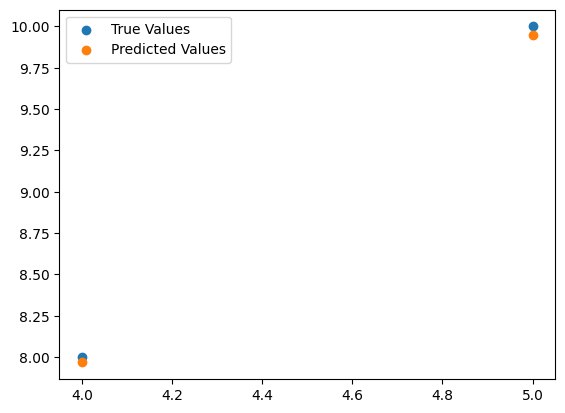

In [73]:
import matplotlib.pyplot as plt

plt.scatter(x_val.numpy(), y_val.numpy(), label="True Values")
plt.scatter(x_val.numpy(), val_pred.numpy(), label="Predicted Values")
plt.legend()

plt.show()